
# Project: Patient‑Readable Clinical Trial Summaries

**Goal (Milestone P2):** Build a reproducible **data understanding + preprocessing + descriptive statistics** notebook that prepares us to generate **patient‑friendly summaries** from English clinical trial records https://huggingface.co/datasets/louisbrulenaudet/clinical-trials.
We focus on three pillars:
1. **Too much jargon** → measure complexity and technical vocabulary.
2. **Patient‑friendly description** → characterize what we need to simplify (length, readability).
3. **Transparent explanations** → prepare metadata to support glossaries and “who/what/why/how” summaries.

**What this notebook shows:**
- That we can **load and handle** the dataset at scale.
- That we **understand the data** (formats, missingness, distributions, correlations).
- That we have **filters and a working split** ready for modeling.
- That we have **clear next steps** toward simplification + summarization.



We load the Hugging Face dataset **`louisbrulenaudet/clinical-trials`**, report the number of rows,
and print the feature names and types

In [1]:
from datasets import load_dataset

# Load the complete dataset
dataset = load_dataset("louisbrulenaudet/clinical-trials", split="train")

print(f"Dataset size: {len(dataset)}")
print(f"Features: {dataset.features}")

C:\Users\Ilinca\miniconda3\envs\nlp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset size: 541897
Features: {'nct_id': Value('string'), 'updated_at': Value('timestamp[us]'), 'brief_title': Value('string'), 'official_title': Value('string'), 'acronym': Value('string'), 'study_type': Value('string'), 'overall_status': Value('string'), 'study_first_submit_date': Value('timestamp[ms]'), 'start_date': Value('timestamp[ms]'), 'primary_completion_date': Value('timestamp[ms]'), 'completion_date': Value('timestamp[ms]'), 'phases': List(Value('string')), 'enrollment_count': Value('float64'), 'minimum_age': Value('float64'), 'maximum_age': Value('float64'), 'sex': Value('string'), 'healthy_volunteers': Value('bool'), 'brief_summary': Value('string'), 'detailed_description': Value('string'), 'eligibility_criteria': Value('string'), 'lead_sponsor_name': Value('string'), 'lead_sponsor_class': Value('string'), 'org_study_id_info': {'id': Value('string'), 'link': Value('string'), 'type': Value('string')}, 'why_stopped': Value('string'), 'expanded_access_info': {'hasExpandedAcc

In [9]:
print("Number of features: ", len(dataset.features))

Number of features:  46


Our main features will be "detailed_description" and "brief_summary". Let's see how many rows are missing those features

In [10]:
print(len(dataset))
print("Without brief summary: ", dataset['brief_summary'].count(None))
print("Without detailed_description: ", dataset['detailed_description'].count(None))

541897
Without brief summary:  920
Without detailed_description:  175870


Looks like 1/3 of the data is missing the detailed description. A big number, but we consider that it still leaves us enough samples to work on. Let's look at some random samples:

In [11]:
import textwrap
import random
# --- Random rows peek ---
k = min(3, len(dataset))
idxs = random.sample(range(len(dataset)), k) if len(dataset) >= k else list(range(len(dataset)))
peek = dataset.select(idxs)
for i, row in enumerate(peek):
    print(f"\n--- Random row {i+1} (index={idxs[i]}) ---")
    # Print key fields for readability; you can expand this list as needed
    for key in [
        "nct_id", "brief_title", "study_type", "overall_status",
        "phases", "conditions", "minimum_age", "maximum_age", "sex",
        "brief_summary", "detailed_description"
    ]:
        if key in row:
            val = row[key]
            if isinstance(val, str) and len(val) > 500:
                val = textwrap.shorten(val, width=500, placeholder=" ...")
            print(f"{key}: {val}")


--- Random row 1 (index=302470) ---
nct_id: NCT02836834
brief_title: Safety, Tolerability, Pharmacokinetics & Pharmacodynamics of an Anti-PD-1 mAb for Patients With Advanced Solid Tumors
study_type: INTERVENTIONAL
overall_status: UNKNOWN
phases: ['PHASE1']
conditions: ['Lymphoma', 'Lung Cancer']
minimum_age: 18.0
maximum_age: 65.0
sex: ALL
brief_summary: The primary objective is to assess the safety and tolerability of JS-001 in subjects with various advanced or recurrent malignancies, including solid tumors and lymphomas, and to evaluate its preliminary efficacy. The secondary objectives are to: 1) characterize the single-dose and multi-dose pharmacokinetic (PK) profile of JS-001, 2) characterize the immunogenicity of JS-001; 3) assess the dose-efficacy relationship of JS-001 single agent, and 4) preliminarily evaluate biomarkers associated ...
detailed_description: OVERVIEW This is a Phase 1, open-label, dose-escalation study of JS-001, a humanized monoclonal IgG4 antibody targeting

After manually looking through the dataset, we selected the features we found relevant and created a feature plan. This table documents which fields we **keep**, which are **optional**, and which we **drop**, including the rationale.

In [2]:
import pandas as pd

# --- Feature plan (keep/drop + justification) ---
plan_rows = [
    dict(field="nct_id", use="keep", role="identifier", justification="Unique trial ID for traceability/provenance."),
    dict(field="detailed_description", use="keep", role="primary_text", justification="Main source for simplification & summarization."),
    dict(field="brief_summary", use="keep", role="reference_text", justification="Comparison target for coverage & readability diffs."),
    dict(field="brief_title", use="keep", role="aux_text", justification="Concise signal of condition/intervention; useful for summaries."),
    dict(field="official_title", use="keep", role="aux_text", justification="Formal title; may provide specific terminology."),
    dict(field="study_type", use="keep", role="metadata", justification="Context for wording (interventional vs observational)."),
    dict(field="overall_status", use="keep", role="metadata", justification="Status cues phrasing and may affect inclusion."),
    dict(field="phases", use="drop", role="metadata", justification="Do not provide valuable information for trail description."),
    dict(field="conditions", use="keep", role="metadata", justification="Key to patient relevance; appears in the summary."),
    dict(field="minimum_age", use="keep", role="metadata", justification="Eligibility snippet (age bounds)."),
    dict(field="maximum_age", use="keep", role="metadata", justification="Eligibility snippet (age bounds)."),
    dict(field="sex", use="keep", role="metadata", justification="Eligibility snippet (sex)."),
    dict(field="healthy_volunteers", use="keep", role="metadata", justification="May be useful for eligibility sentences."),
    dict(field="eligibility_criteria", use="keep", role="aux_text", justification="Source for ‘for whom’ phrasing; optional extraction."),
    dict(field="lead_sponsor_name", use="optional", role="metadata", justification="Provenance; not typically in lay summary."),
    dict(field="lead_sponsor_class", use="drop", role="metadata", justification="Likely irrelevant for patient-facing text."),
    dict(field="enrollment_count", use="optional", role="metadata", justification="Contextual statistic; might be mentioned sparingly."),
    dict(field="start_date", use="optional", role="metadata", justification="Timeline context if needed."),
    dict(field="primary_completion_date", use="drop", role="metadata", justification="Timeline context probably needed."),
    dict(field="completion_date", use="drop", role="metadata", justification="Timeline context probably not needed."),
    dict(field="keywords", use="keep", role="aux_text", justification="May seed domain vocabulary/jargon detection."),
    dict(field="locations", use="optional", role="metadata", justification="High-level geography; not always needed in summary."),
    dict(field="overall_officials", use="drop", role="metadata", justification="Low value for lay summary text."),
    dict(field="outcomes", use="keep", role="metadata", justification="Primary/secondary measures inform ‘what is measured’."),
    dict(field="design_info", use="keep", role="metadata", justification="Randomization/masking/purpose → plain-language explanation."),
    dict(field="mesh_terms", use="optional", role="metadata", justification="Useful for controlled vocabulary/jargon mapping."),
    dict(field="condition_browse_module", use="drop", role="metadata", justification="Taxonomy signs; probably not needed."),
    dict(field="intervention_browse_module", use="drop", role="metadata", justification="Taxonomy signs; probably not."),
    dict(field="why_stopped", use="optional", role="metadata", justification="If terminated, can inform a cautionary note in summary."),
    dict(field="expanded_access_info", use="drop", role="metadata", justification="Out-of-scope for lay summary generation."),
    dict(field="org_study_id_info", use="drop", role="metadata", justification="Administrative; not needed for text generation."),
    dict(field="arm_groups", use="optional", role="metadata", justification="If present, may help clarify groups in lay terms."),
    dict(field="interventions", use="keep", role="metadata", justification="Names/types of interventions: key to ‘what is tested’."),
    dict(field="study_references", use="drop", role="metadata", justification="Not needed for lay summary text."),
    dict(field="misc_info_module", use="drop", role="metadata", justification="Likely non-essential for our task."),
    dict(field="updated_at", use="optional", role="metadata", justification="Recency; can be used for filtering if needed."),
    dict(field="last_update_submit_qc_date", use="drop", role="metadata", justification="Quality control recency; drio for simplicity."),
    dict(field="last_update_post_date_struct", use="drop", role="metadata", justification="Administrative; drop for simplicity."),
    dict(field="study_first_post_date_struct", use="drop", role="metadata", justification="Administrative; drop for simplicity."),
    dict(field="study_first_submit_date", use="drop", role="metadata", justification="Administrative; drop for simplicity."),
    dict(field="std_ages", use="optional", role="metadata", justification="Age categories; redundant with min/max but handy."),
    dict(field="sampling_method", use="optional", role="metadata", justification="May inform wording but often technical."),
    dict(field="oversight_has_dmc", use="drop", role="metadata", justification="Oversight detail; too technical for lay summary."),
    dict(field="collaborators", use="drop", role="metadata", justification="Attribution; not needed in lay summary."),
    dict(field="acronym", use="drop", role="metadata", justification="Not relevant"),
    dict(field="study_population", use="keep", role="metadata", justification="Summary of the needed study population."),
]
plan_df = pd.DataFrame(plan_rows, columns=["field","use","role","justification"])
print(len(plan_df))
plan_df.to_csv("feature_plan.csv", index=False)

def df_to_markdown(df: pd.DataFrame) -> str:
    return df.to_markdown(index=False)

print("\n=== Feature Plan (Markdown) ===")
print(plan_df.to_markdown(index=False))


46

=== Feature Plan (Markdown) ===
| field                        | use      | role           | justification                                                   |
|:-----------------------------|:---------|:---------------|:----------------------------------------------------------------|
| nct_id                       | keep     | identifier     | Unique trial ID for traceability/provenance.                    |
| detailed_description         | keep     | primary_text   | Main source for simplification & summarization.                 |
| brief_summary                | keep     | reference_text | Comparison target for coverage & readability diffs.             |
| brief_title                  | keep     | aux_text       | Concise signal of condition/intervention; useful for summaries. |
| official_title               | keep     | aux_text       | Formal title; may provide specific terminology.                 |
| study_type                   | keep     | metadata       | Context for wo

How can we combine all the features we find relevant for the summarization? (Initial idea: create a new text like "title: ..., description: ..., eligibility criteria: ..., ....."

In [13]:
#TODO

We compute **missing values** per field and visualize top offenders.
**Why:** understanding completeness helps us define **filters** (e.g., drop rows with empty `detailed_description`) and
estimate how much usable data remains for modeling. **TAKES 4 MIN TO RUN**

In [3]:
# --- Step 2: Assess data volume & missingness ---

import numpy as np
import math
import matplotlib.pyplot as plt
from collections.abc import Mapping, Sequence

# 2.1 Choose fields to assess (driven by your plan)
# We'll check all "keep" + "optional" fields that are present in the dataset.
candidate_fields = [f for f in plan_df.query("use in ['keep']")["field"].tolist()
                    if f in dataset.column_names]

# 2.2 Helpers to decide what's "missing" (works for str, lists, dicts, None, NaN)
def is_missing_value(v):
    if v is None:
        return True
    # NaN (numbers)
    try:
        if isinstance(v, float) and math.isnan(v):
            return True
    except Exception:
        pass
    # Empty string or whitespace-only
    if isinstance(v, str):
        return len(v.strip()) == 0
    # Empty list/tuple
    if isinstance(v, Sequence) and not isinstance(v, (str, bytes)):
        return len(v) == 0
    # Empty dict
    if isinstance(v, Mapping):
        return len(v) == 0
    return False

# 2.3 Compute missingness per field (percentage)
missing_rows = []
N = len(dataset)
for field in candidate_fields:
    col = dataset[field]
    # For Arrow-backed columns, iterating is ok; if too slow, sample (but try full first)
    miss_cnt = sum(is_missing_value(v) for v in col)
    missing_rows.append({
        "field": field,
        "num_missing": miss_cnt,
        "pct_missing": 100.0 * miss_cnt / N
    })

missing_df = pd.DataFrame(missing_rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
missing_df


,field,num_missing,pct_missing
0,interventions,541897,100.000000
1,study_population,420133,77.530047
2,maximum_age,254447,46.954864
3,keywords,201556,37.194522
4,detailed_description,175870,32.454507
5,minimum_age,36025,6.647942
6,outcomes,17510,3.231241
7,healthy_volunteers,13771,2.541258
8,official_title,9986,1.842786
9,design_info,4664,0.860680


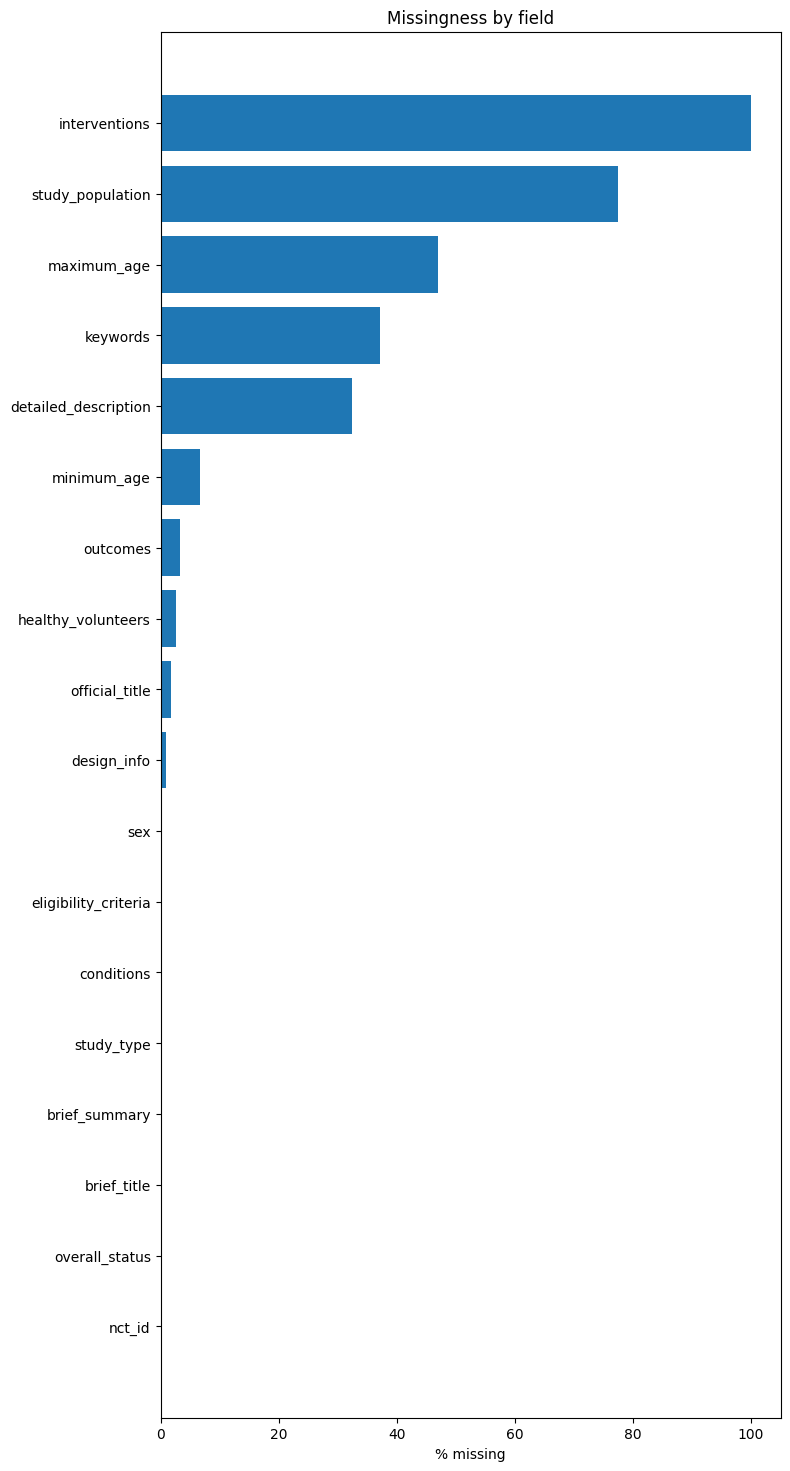

In [31]:
# 2.4 Visualize missingness (top 30 by % missing)
plt.figure(figsize=(8, len(missing_df)))
plt.barh(missing_df["field"], missing_df["pct_missing"])
plt.gca().invert_yaxis()
plt.xlabel("% missing")
plt.title("Missingness by field")
plt.show()

Looks like interventions are missing every time, so we will exclude those from our plan. Study_population is also missing a lot but we fill it might give is valuable input when present and might be easy to fill missing values (with something like "general population"; same for maximum age). At the same time keywords are missing too many times so we decided to set them as optional, as it might not be that important for summarization.

In [4]:
def drop_interventions(row):
    if row["field"] == "interventions":
        row["use"] = "drop"
    return row
def drop_keywords(row):
    if row["field"] == "keywords":
        row["use"] = "optional"
    return row
plan_df.apply(lambda r: drop_interventions(r), axis=1)
plan_df.apply(lambda r: drop_keywords(r), axis=1)
plan_df.to_csv("feature_plan.csv", index=False)


The features **detailed_description** and **brief_summary** will be mandatory in order to compute and evaluate the patient-friendly summary and jargon explanation **TAKES 5 MIN TO RUN**

In [6]:
# 2.5 Decide & apply filters for a high-quality working dataset
# Rules (adjust if you prefer):
# - Must have non-empty detailed_description (primary text)
# - Optionally require brief_summary for later comparison (set require_brief_summary=True to enforce)
require_brief_summary = True

primary_text_field = plan_df.query("role == 'primary_text' and use == 'keep'")["field"].iloc[0]
ref_text_field = "brief_summary" if "brief_summary" in dataset.column_names else None

def row_ok(example):
    if is_missing_value(example.get(primary_text_field, None)):
        return False
    if require_brief_summary and ref_text_field and is_missing_value(example.get(ref_text_field, None)):
        return False
    return True

filtered_ds = dataset.filter(row_ok)

print(f"Original rows: {len(dataset):,}")
print(f"Filtered rows: {len(filtered_ds):,}")
print(f"Retained: {100.0*len(filtered_ds)/len(dataset):.2f}%")

# Keep a reference for later steps
work_ds = filtered_ds


Original rows: 541,897
Filtered rows: 366,027
Retained: 67.55%


Let's look again at what features are missing how many entries **TAKES 6 MIN TO RUN**

In [7]:
candidate_fields_new = [f for f in plan_df.query("use in ['keep']")["field"].tolist()
                    if f in filtered_ds.column_names]


# 2.3 Compute missingness per field (percentage)
missing_rows = []
N = len(filtered_ds)
for field in candidate_fields_new:
    col = filtered_ds[field]
    # For Arrow-backed columns, iterating is ok; if too slow, sample (but try full first)
    miss_cnt = sum(is_missing_value(v) for v in col)
    missing_rows.append({
        "field": field,
        "num_missing": miss_cnt,
        "pct_missing": 100.0 * miss_cnt / N
    })

missing_df_new = pd.DataFrame(missing_rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
missing_df_new

,field,num_missing,pct_missing
0,study_population,282747,77.247580
1,maximum_age,168768,46.108074
2,minimum_age,24940,6.813705
3,outcomes,11696,3.195393
4,healthy_volunteers,8087,2.209400
5,official_title,3261,0.890918
6,design_info,2715,0.741749
7,sex,233,0.063657
8,eligibility_criteria,38,0.010382
9,conditions,12,0.003278


**Decision**: we can eliminate the rows that are missing features up until **outcomes** and fill in missing values for **minimum_age**, **keywords**, **maximum_age**, **study_population**
We decided to fill the values for the rows that have the maximum_age or minimum_age missing in order to not loose more data. For the rows where maximum_age is missing we will fill it with the maximum value for this field. For the rows where minimum_age is missing, we will fill it with value 0 (y/o). We decided to fill the age restrictions like this, because we assumed that if the maximum_age or minimum_age fields were not filled it means that there are no restrictions regarding them.
For the rows that have missing study_population, we still want to keep them, because we consider that where the information exists is of great value. In order to not contradict the eligibility criteria (there can be information about study population, but not represented in this field) and not influence in any manner we will add "no comment".

In [8]:
max_age_value = max(
    [x for x in filtered_ds["maximum_age"] if x is not None]
)

def fill_missing(example):
    example["maximum_age"] = example["maximum_age"] if example["maximum_age"] is not None else max_age_value
    example["minimum_age"] = example["minimum_age"] if example["minimum_age"] is not None else 0
    example["study_population"] = example["study_population"] if example["study_population"] is not None else "no comment"
    return example

filtered_ds = filtered_ds.map(fill_missing)
work_ds = filtered_ds

In [9]:
fields_to_check = [
    "outcomes",
    "healthy_volunteers",
    "official_title",
    "design_info",
    "sex",
    "eligibility_criteria",
    "conditions",
]

filtered_ds = filtered_ds.filter(
    lambda example: all(
        example[field] not in [None, ""] for field in fields_to_check
    )
)

In [10]:
# check the changes
candidate_fields_new = [f for f in plan_df.query("use in ['keep']")["field"].tolist()
                    if f in filtered_ds.column_names]


# 2.3 Compute missingness per field (percentage)
missing_rows = []
N = len(filtered_ds)
for field in candidate_fields_new:
    col = filtered_ds[field]
    # For Arrow-backed columns, iterating is ok; if too slow, sample (but try full first)
    miss_cnt = sum(is_missing_value(v) for v in col)
    missing_rows.append({
        "field": field,
        "num_missing": miss_cnt,
        "pct_missing": 100.0 * miss_cnt / N
    })

missing_df_new = pd.DataFrame(missing_rows).sort_values("pct_missing", ascending=False).reset_index(drop=True)
missing_df_new

,field,num_missing,pct_missing
0,nct_id,0,0.0
1,detailed_description,0,0.0
2,brief_summary,0,0.0
3,brief_title,0,0.0
4,official_title,0,0.0
5,study_type,0,0.0
6,overall_status,0,0.0
7,conditions,0,0.0
8,minimum_age,0,0.0
9,maximum_age,0,0.0


Let's look in detail at length of the detailed_description and brief_summary

detailed_description — avg words (sample): 296.1  | median: 193 | max: 5232
brief_summary — avg words (sample): 91.6  | median: 61 | max: 854


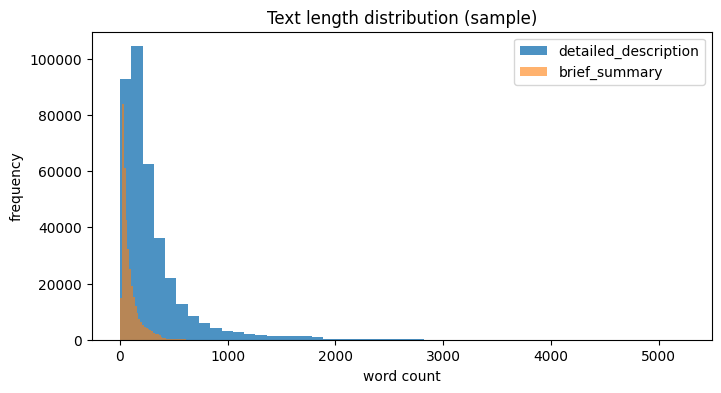

In [15]:
# 2.6 Quick quality spot-check: lengths of primary and reference texts
# def safe_len_words(x):
#     if x is None or not isinstance(x, str): return 0
#     return len(x.split())

sample_size = len(work_ds)
sample = work_ds.select(range(sample_size))

primary_lens = [len(t.split()) for t in sample[primary_text_field]]
ref_lens = [len(t.split()) for t in sample[ref_text_field]] if ref_text_field else []

print(f"{primary_text_field} — avg words (sample): {np.mean(primary_lens):.1f}  | median: {np.median(primary_lens):.0f} | max: {np.max(primary_lens):.0f}")
if ref_text_field:
    print(f"{ref_text_field} — avg words (sample): {np.mean(ref_lens):.1f}  | median: {np.median(ref_lens):.0f} | max: {np.max(ref_lens):.0f}")

plt.figure(figsize=(8,4))
plt.hist(primary_lens, bins=50, alpha=0.8, label=primary_text_field)
if ref_text_field:
    plt.hist(ref_lens, bins=50, alpha=0.6, label=ref_text_field)
plt.xlabel("word count")
plt.ylabel("frequency")
plt.title("Text length distribution (sample)")
plt.legend()
plt.show()


The text length is reasonable to work with. We have to think if we need to do anything with the very long ones. We are going to check the exact number of rows that have very long detailed description, in bin sizes of 1000 words.

In [16]:
# Define your ranges (in words)
bins = [(0, 1000), (1000, 2000), (2000, 3000), (3000, 4000), (4000, 5000), (5000, 6000)]

# Function to count words in each description
def word_count(text):
    if text is None:
        return 0
    return len(str(text).split())

# Count number of examples per bin
counts = []
for lower, upper in bins:
    count = sum(
        1
        for text in filtered_ds["detailed_description"]
        if lower < word_count(text) <= upper
    )
    counts.append((f"{lower}-{upper}", count))

# Print results neatly
for label, count in counts:
    print(f"{label} words: {count}")


0-1000 words: 329545
1000-2000 words: 13272
2000-3000 words: 1101
3000-4000 words: 345
4000-5000 words: 209
5000-6000 words: 3


After checking the length of the detailed description, we can see that there are not a lot of rows that have the detailed description longer than 2000 words. We do not see at this point a problem with the length of this feature, so we decided that we will keep all the rows for now. However, we will have this in mind for later on and will check how the model behaves for the ones with a long description.

We use textstat to calculate the readability for our features: https://www.kaggle.com/code/yhirakawa/textstat-how-to-evaluate-readability **TAKES 7 MIN TO RUN**

In [44]:
# Readability (Flesch–Kincaid, Gunning Fog, etc.) using textstat
# Install on the fly if not available
import textstat

def readability_metrics(text: str):
    return {
        "fk_grade": textstat.flesch_kincaid_grade(text),
        "gunning_fog": textstat.gunning_fog(text),
        "smog_index": textstat.smog_index(text),
        "flesch_reading_ease": textstat.flesch_reading_ease(text),
    }

text_fields = [primary_text_field, ref_text_field]

# Compute readability on a smaller sample for speed
read_sample_size = min(5000, sample_size)
read_rows = []
for i in range(read_sample_size):
    rr = {"idx": i}
    for f in text_fields:
        t = sample[f][i]
        rr.update({f"{f}__{k}": v for k, v in readability_metrics(t).items()})
    read_rows.append(rr)

read_df = pd.DataFrame(read_rows)

# Summaries
read_summ_rows = []
for f in text_fields:
    sub = read_df[[c for c in read_df.columns if c.startswith(f"{f}__")]]
    read_summ_rows.append({
        "field": f,
        "fk_grade_mean": np.nanmean(sub[f"{f}__fk_grade"]),
        "gunning_fog_mean": np.nanmean(sub[f"{f}__gunning_fog"]),
        "smog_index_mean": np.nanmean(sub[f"{f}__smog_index"]),
        "flesch_reading_ease_mean": np.nanmean(sub[f"{f}__flesch_reading_ease"]),
    })
readability_summary_df = pd.DataFrame(read_summ_rows)
readability_summary_df


,field,fk_grade_mean,gunning_fog_mean,smog_index_mean,flesch_reading_ease_mean
0,detailed_description,15.634223,18.857684,16.546353,24.387276
1,brief_summary,17.124030,20.294099,17.406299,18.403542


After taking a closer look at https://www.kaggle.com/code/yhirakawa/textstat-how-to-evaluate-readability to understand the metrics, we can see that our current text is hard to understand and read. We need to see exactly which metric is best to use and create a loss function

In [ ]:
#TODO

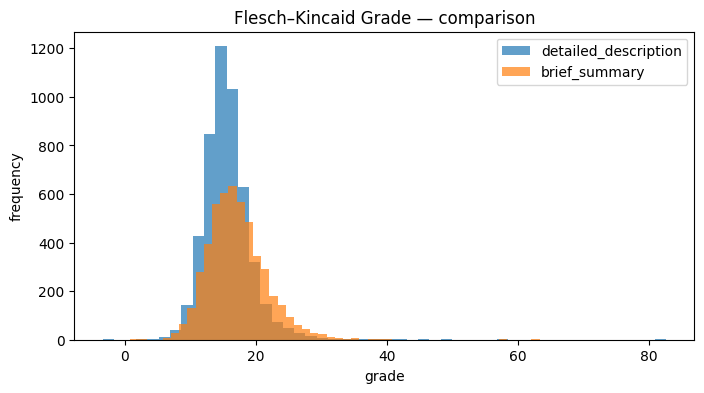

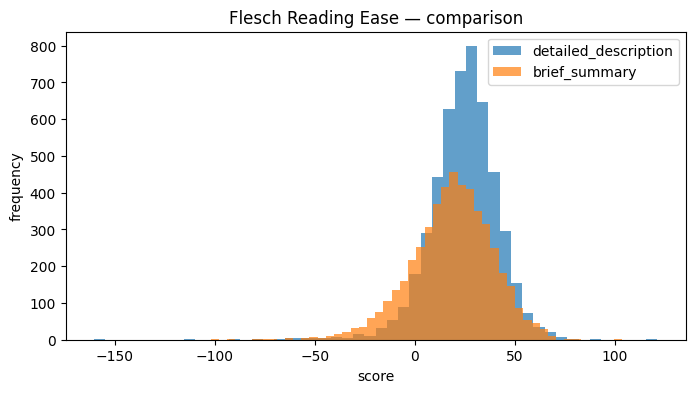

In [45]:
# If both primary and reference exist, compare readability distributions
if ref_text_field:
    plt.figure(figsize=(8,4))
    plt.hist(read_df[f"{primary_text_field}__fk_grade"], bins=50, alpha=0.7, label=primary_text_field)
    plt.hist(read_df[f"{ref_text_field}__fk_grade"], bins=50, alpha=0.7, label=ref_text_field)
    plt.title("Flesch–Kincaid Grade — comparison")
    plt.xlabel("grade"); plt.ylabel("frequency"); plt.legend(); plt.show()

    plt.figure(figsize=(8,4))
    plt.hist(read_df[f"{primary_text_field}__flesch_reading_ease"], bins=50, alpha=0.7, label=primary_text_field)
    plt.hist(read_df[f"{ref_text_field}__flesch_reading_ease"], bins=50, alpha=0.7, label=ref_text_field)
    plt.title("Flesch Reading Ease — comparison")
    plt.xlabel("score"); plt.ylabel("frequency"); plt.legend(); plt.show()


We understand that the text is hard to read and understand, but let's look at exactly how much jargon we have there **TAKES LONG TO RUN**

In [53]:
import spacy
nlp = spacy.load("en_core_web_sm")
def iter_docs(texts, batch_size=64):
    for doc in nlp.pipe(texts, batch_size=batch_size, disable=[]):
        yield doc
tok_sample_size = min(2000, len(work_ds))
tok_sample = work_ds.select(range(tok_sample_size))

In [54]:
biomed_suffixes = (
    "itis","emia","osis","otomy","ectomy","algia","pathy","oma","genic","genic","phage",
    "phagia","pharm","lysis","cardio","neuro","hepato","derm","pulmo","renal","oncol",
    "immuno","therap","toxic","metabol","genom","nephro","hemo","hema","gastro","neuro",
    "ophthal","otol","psycho","endo","osteo","myo","hepatic","pulmonary","renal"
)
biomed_substrings = (
    "placebo","randomiz","double-blind","intervention","biomarker","chemother","radiother",
    "metast","carcin","tumor","oncolog","immun", "biologic","antibody","mg","ml","dose","dosing",
    "adverse","endpoint","efficacy","safety"
)

# Build doc frequency for non-stopword alphabetic lemmas in primary_text_field
docs_nonstop = []
for doc in iter_docs([t for t in tok_sample[primary_text_field]]):
    lemmas = set([t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop])
    docs_nonstop.append(lemmas)

from collections import Counter
df_counter = Counter()
for lemmas in docs_nonstop:
    df_counter.update(lemmas)

num_docs = len(docs_nonstop)
def doc_freq(token_lemma):
    return df_counter[token_lemma] / max(1, num_docs)

def looks_jargony(tok: str) -> bool:
    if len(tok) >= 3 and tok.isupper():  # acronym
        return True
    if any(tok.endswith(suf) for suf in biomed_suffixes):
        return True
    if any(sub in tok for sub in biomed_substrings):
        return True
    if "-" in tok and len(tok) > 6:
        return True
    return False

# Classify tokens & compute jargon density per doc (primary_text_field)
jargon_threshold = 0.01  # tokens appearing in <=1% of docs are considered rare
jargon_examples = Counter()

jargon_density_list = []
for doc in iter_docs([t for t in tok_sample[primary_text_field]]):
    content = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
    if not content:
        jargon_density_list.append(0.0); continue
    jargon_tokens = [
        w for w in content
        if (doc_freq(w) <= jargon_threshold) or looks_jargony(w)
    ]
    jargon_density = len(jargon_tokens) / max(1, len(content))
    jargon_density_list.append(jargon_density)
    jargon_examples.update(jargon_tokens)

jargon_density_arr = np.array(jargon_density_list)
print(f"Jargon density — mean: {np.mean(jargon_density_arr):.3f} | median: {np.median(jargon_density_arr):.3f}")


Jargon density — mean: 0.267 | median: 0.264


In [55]:
# Show top-25 "jargon" tokens (by frequency under the above heuristic)
top_jargon = pd.DataFrame(jargon_examples.most_common(25), columns=["token","count"])
top_jargon

,token,count
0,intervention,1242
1,dose,1134
2,analysis,691
3,randomize,657
4,mg,600
5,safety,579
6,efficacy,478
7,tumor,415
8,placebo,411
9,adverse,303


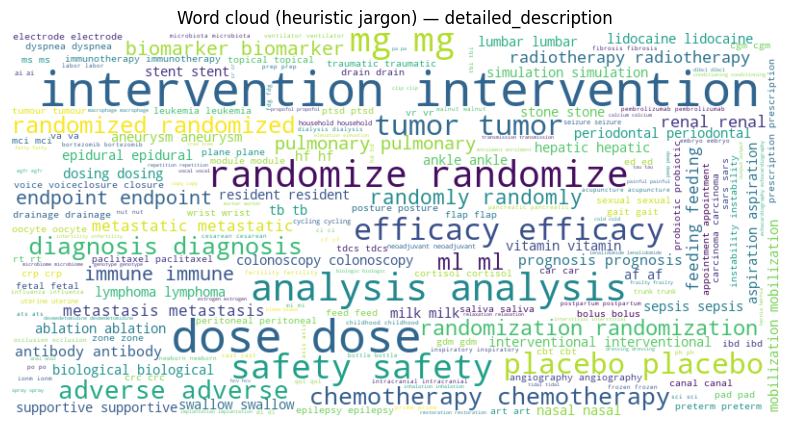

In [59]:
from wordcloud import WordCloud
def show_wordcloud_from_counter(counter, title):
    # Build a single string by repeating tokens by frequency
    text = " ".join([tok for tok, cnt in counter.items() for _ in range(cnt)])
    if not text.strip():
        print(f"(empty wordcloud for {title})")
        return
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()
# Word clouds: before vs after stopword removal (primary field) — already done above
# Add one more: word cloud of "jargon" tokens (heuristic)
jargon_wc_counter = Counter({tok: cnt for tok, cnt in jargon_examples.items() if cnt >= 5})
show_wordcloud_from_counter(jargon_wc_counter, f"Word cloud (heuristic jargon) — {primary_text_field}")


I don't really like how we measure jargon. We might find a better way

In [ ]:
#TODO

We could use a simple english metric to identify and measure the jargons. Below is a piece of code to identify the technical terms( as of now, it only considers a small amount of words). 
There is also a much better metric ( "wordfreq" )to enhance it, the implementation for the same is two cells down.

In [ ]:
import re
from collections import Counter

# Extract the 'detailed_description' column
texts = [str(x) for x in dataset["detailed_description"] if x is not None]

# Tokenize the text
def tokenize(text):
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-]+\b", text.lower())

all_words = []
for text in texts:
    all_words.extend(tokenize(text))

# Load a simple English word list
def load_common_words():
    # TODO: replace with larger list if available ( added a baseline for testing now)
    common_words = set("""
    a about above after again against all am an and any are aren't as at be because been before
    being below between both but by can can't come could couldn't did didn't do does doesn't doing
    don't down during each few for from further had hadn't has hasn't have haven't having he he'd
    he'll he's her here here's hers herself him himself his how how's i i'd i'll i'm i've if in into
    is isn't it it's its itself just know like make many me might more most must my myself no nor not
    of off on once only or other our ours ourselves out over own said same see should shouldn't so
    some such take than that that's the their theirs them themselves then there there's these they
    they'd they'll they're they've this those through to too under until up very was wasn't we we'd
    we'll we're we've were weren't what what's when when's where where's which while who who's whom
    why why's with won't would wouldn't you you'd you'll you're you've your yours yourself yourselves
    """.split())
    return common_words

common_words = load_common_words()

# Identify uncommon (technical/jargon) words
def identify_jargon(words, common_words, min_len=4):
    return Counter([w for w in words if w not in common_words and len(w) >= min_len])

jargon_counts = identify_jargon(all_words, common_words)

# Compute Simple English Metric
def simple_english_metric(total_words, jargon_count):
    return round((jargon_count / total_words) * 100, 2)

metric = simple_english_metric(len(all_words), len(jargon_counts))

# Display results
print(f"Total words: {len(all_words)}")
print(f"Unique jargon terms: {len(jargon_counts)}")
print(f"Simple English Metric: {metric}% jargon\n")

print(f"{'Term':<25} {'Count':>6}")
print("-" * 35)
for term, count in jargon_counts.most_common(100):  # Top 100 jargon terms
    print(f"{term:<25} {count:>6}")

Implementation using "wordfreq". Read more : https://chatgpt.com/share/69087dc8-0db4-8009-b2b5-6324c561aa1c 

In [ ]:
# !pip install wordfreq

from wordfreq import zipf_frequency
import re
from collections import Counter

# Extract 'detailed_description' column
texts = [str(x) for x in dataset["detailed_description"] if x is not None]

# Tokenize text
def tokenize(text):
    return re.findall(r"\b[a-zA-Z][a-zA-Z\-]+\b", text.lower())

all_words = []
for text in texts:
    all_words.extend(tokenize(text))

print(f"Total words extracted: {len(all_words)}")

# Determine which words are common using wordfreq
def is_common_word(word, threshold=4.5):
    """
    Uses Zipf frequency (log scale from 0–7):
    - ~7 = very common (e.g., 'the')
    - ~4–5 = common everyday English
    - <4 = rare/technical terms
    """
    return zipf_frequency(word, "en") >= threshold

# Identify jargon
def identify_jargon(words, threshold=4.5, min_len=4):
    jargon = [w for w in words if len(w) >= min_len and not is_common_word(w, threshold)]
    return Counter(jargon)

jargon_counts = identify_jargon(all_words, threshold=4.5)

# Compute Simple English Metric
def simple_english_metric(total_words, jargon_count):
    if total_words == 0:
        return 0
    return round((jargon_count / total_words) * 100, 2)

metric = simple_english_metric(len(all_words), len(jargon_counts))

# Display results
print("\n=== Simple English Jargon Analysis ===")
print(f"Unique jargon terms: {len(jargon_counts)}")
print(f"Simple English Metric: {metric}% jargon\n")

print(f"{'Term':<25} {'Count':>6}")
print("-" * 35)
for term, count in jargon_counts.most_common(100):
    print(f"{term:<25} {count:>6}")

We need to see what would the pipline would like; last question here: https://chatgpt.com/share/68fe3cca-e764-8011-8eb2-beca631ed2b8

In [ ]:
#TODO